# CenterFusion Training Loop
**Bridges:** `nuscenes_dataset_headache.ipynb` (data) ↔ `centerfusion_walkthrough.ipynb` (model)

Run cells in order. Cell 0 assumes you already have:
- The repo cloned at `/kaggle/working/CenterFusion`
- The nuScenes mini dataset linked at `data/nuscenes`
- Annotations generated by `convert_nuScenes.py` (Cell 4 of the dataset notebook)

If you are starting fresh, run Cells 0–2 of `nuscenes_dataset_headache.ipynb` first.

In [1]:
# Please note that the successing comments are written by Me and not AI.. So if you have any concerns, please tell me directly

#!git clone https://github.com/mrnabati/CenterFusion.git # Clone the repo.
# cwd into the repo folder
#%cd CenterFusion

# Create a symlink (short for symbolic link) (shortcut) to the dataset
#!mkdir -p data/nuscenes
#!ln -s /kaggle/input/datasets/aadimator/nuscenes-mini/* data/nuscenes

# Install only the required dependency for visualization
# Have fun model people with the dependency hell haha (the repo is 6 years old)
!pip install nuscenes-devkit numpy scipy pandas

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.683 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


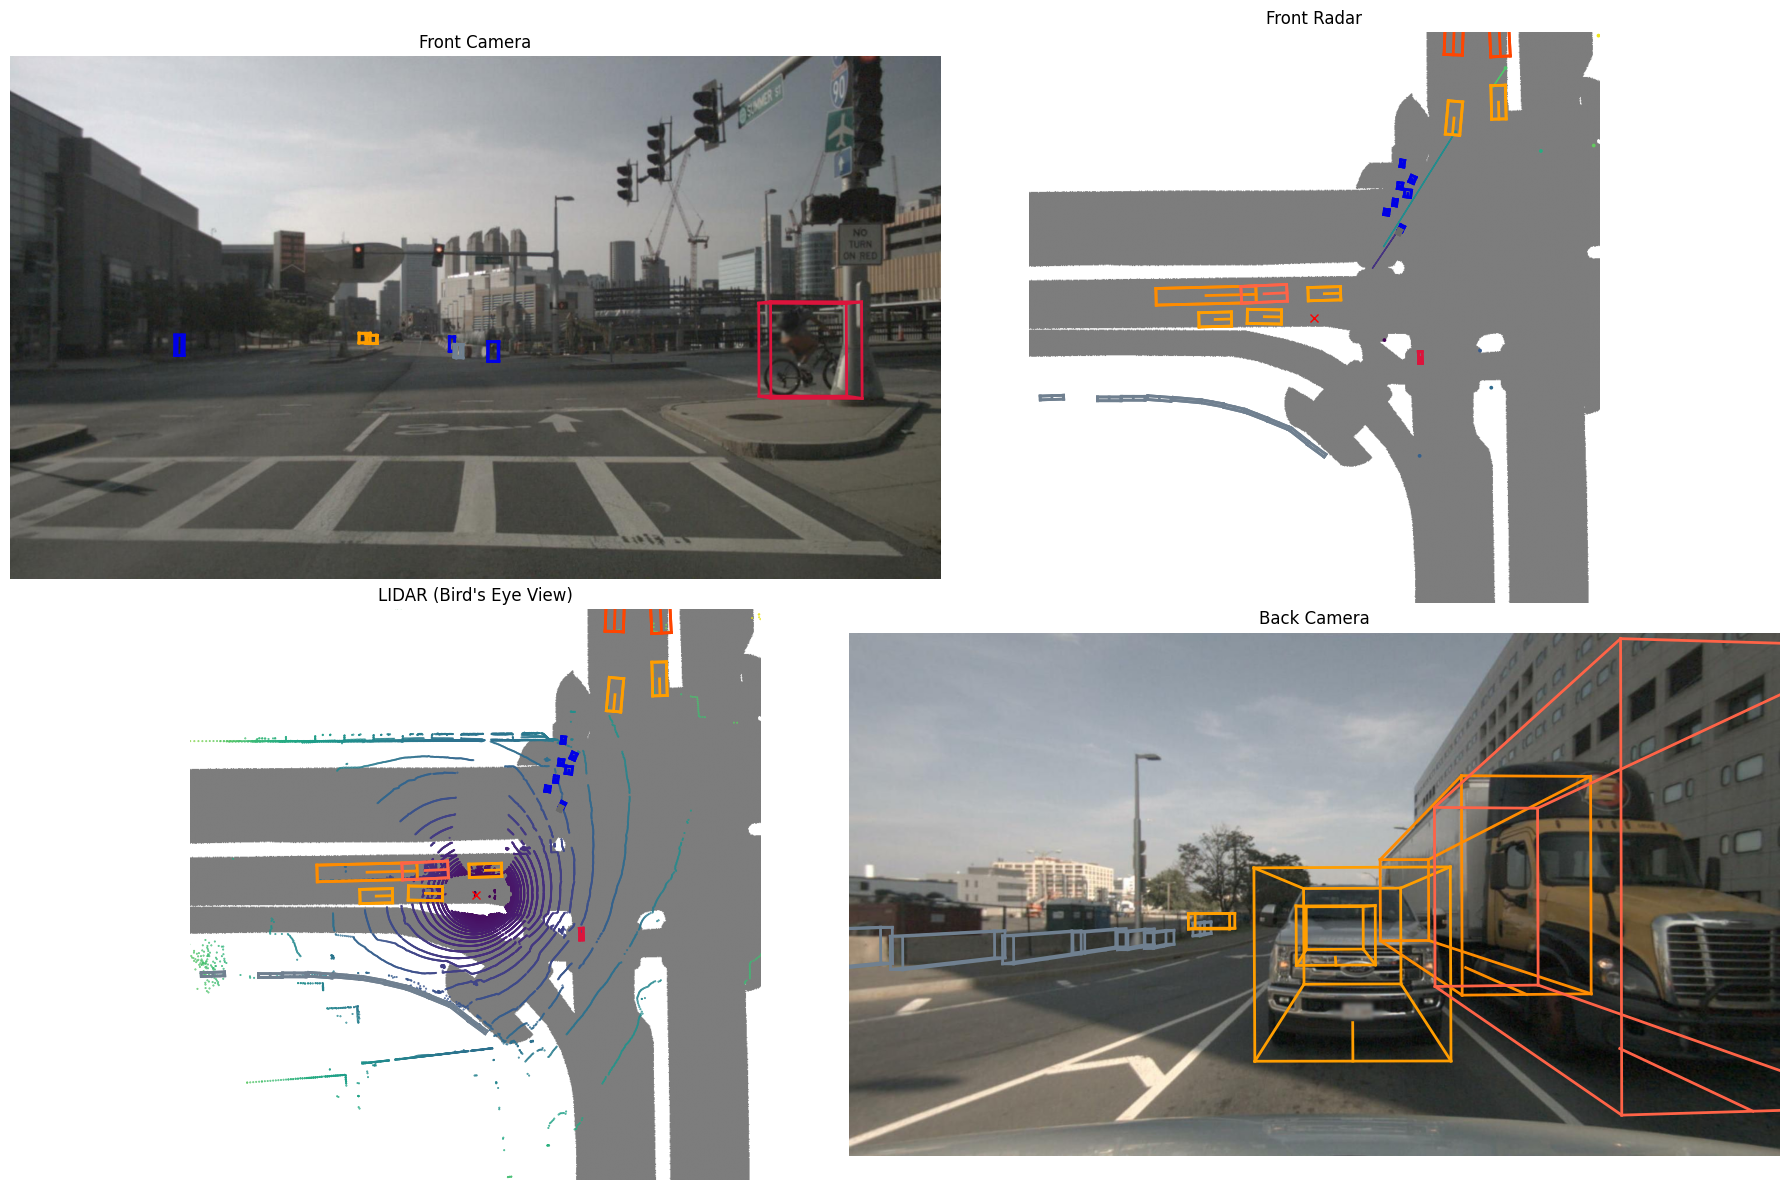

In [2]:
from nuscenes.nuscenes import NuScenes

# 2. Initialize the NuScenes object pointing to Kaggle's read-only input directory
nusc = NuScenes(version='v1.0-mini', dataroot='/kaggle/input/datasets/aadimator/nuscenes-mini', verbose=True)

# 3. Get the very first "Scene" (a 20-second continuous video clip)
my_scene = nusc.scene[2]

# 4. Get the token (ID) for the very first "Sample" (snapshot) in that scene
first_sample_token = my_scene['first_sample_token']

# 5. Fetch the actual sample data using the token
my_sample = nusc.get('sample', first_sample_token)

import matplotlib.pyplot as plt

# 1. Create the afigure and a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 2. Render Front Camera (Top-Left)
# Setting verbose=False prevents the SDK from 'finishing' the plot early
nusc.render_sample_data(my_sample['data']['CAM_FRONT'], ax=axes[0, 0], verbose=False)
axes[0, 0].set_title("Front Camera")

# 3. Render Front Radar (Top-Right)
nusc.render_sample_data(my_sample['data']['RADAR_FRONT'], ax=axes[0, 1], verbose=False)
axes[0, 1].set_title("Front Radar")

# 4. Render LIDAR Top-Down (Bottom-Left)
nusc.render_sample_data(my_sample['data']['LIDAR_TOP'], ax=axes[1, 0], verbose=False)
axes[1, 0].set_title("LIDAR (Bird's Eye View)")

# 5. Render Back Camera (Bottom-Right)
nusc.render_sample_data(my_sample['data']['CAM_BACK'], ax=axes[1, 1], verbose=False)
axes[1, 1].set_title("Back Camera")

# 6. Final display call
plt.tight_layout()
plt.show()

In [3]:
%cd /kaggle/working/CenterFusion/src/tools
# Format the training data
!python convert_nuScenes.py --nusc_path data/nuscenes --nusc_version v1.0-mini --split mini_train

# Format the validation data
!python convert_nuScenes.py --nusc_path data/nuscenes --nusc_version v1.0-mini --split mini_val

/kaggle/working/CenterFusion/src/tools
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.414 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
scene_name scene-0103
scene_name scene-0916
reordering images
mini_val 486 images 4910 boxes
out_path ../../data/nuscenes/annotations_6sweeps/mini_val.json
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.384 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
scene_name scene-0061
scene_name scene-0553
scene_name scene-0655
scene_name scene-0757
scene_name scene-0796
scene_name scene-1077
scene_name scene-1094
scene

In [4]:
%cd /kaggle/working/CenterFusion
!ls -lh /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/

/kaggle/working/CenterFusion
total 207M
-rw-r--r-- 1 root root 164M May 12 20:58 mini_train.json
-rw-r--r-- 1 root root  43M May 12 20:55 mini_val.json


In [6]:
# Crucial for report
import json
from collections import Counter

def analyze_coco_json(file_path):
    print(f"Loading {file_path}...")
    with open(file_path, 'r') as f:
        data = json.load(f)
        
    # 1. Get total images
    num_images = len(data.get('images', []))
    print(f"Total Images: {num_images}")
    
    # 2. Map category IDs to readable names
    cat_mapping = {cat['id']: cat['name'] for cat in data.get('categories', [])}
    
    # 3. Count every 3D bounding box by its class
    category_counts = Counter()
    for ann in data.get('annotations', []):
        cat_name = cat_mapping.get(ann['category_id'], 'Unknown')
        category_counts[cat_name] += 1
        
    print(f"Total Annotations (3D Bounding Boxes): {len(data.get('annotations', []))}")
    print("\n--- Breakdown by Class ---")
    
    # Print sorted by highest count
    for cat_name, count in category_counts.most_common():
        print(f"{cat_name}: {count}")
    print("="*40 + "\n")

# Run it on both files
# Note: If your previous 'ls' command showed these files directly in the CenterFusion folder, 
# change the base_path to "/kaggle/working/CenterFusion/"
base_path = "/kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/"

try:
    analyze_coco_json(base_path + "mini_train.json")
    analyze_coco_json(base_path + "mini_val.json")
except FileNotFoundError as e:
    print(f"File not found. Check if the path is correct: {e}")

Loading /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json...
Total Images: 1938
Total Annotations (3D Bounding Boxes): 14694

--- Breakdown by Class ---
car: 5607
pedestrian: 3568
barrier: 2389
traffic_cone: 1301
truck: 650
bus: 455
motorcycle: 245
construction_vehicle: 230
bicycle: 186
trailer: 63

Loading /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_val.json...
Total Images: 486
Total Annotations (3D Bounding Boxes): 4910

--- Breakdown by Class ---
car: 2894
pedestrian: 1417
motorcycle: 283
truck: 160
bus: 57
bicycle: 56
traffic_cone: 43



In [7]:
# Quick scan of the options file for augmentation keywords
!grep -E "flip|scale|shift|rotate|aug" /kaggle/working/CenterFusion/src/lib/opts.py

    self.parser.add_argument('--flip_test', action='store_true',
                             help='flip data augmentation.')
    self.parser.add_argument('--test_scales', type=str, default='1',
                             help='multi scale test augmentation.')
    self.parser.add_argument('--depth_scale', type=float, default=1,
                             help='not use the random crop data augmentation'
    self.parser.add_argument('--shift', type=float, default=0,
                                  'apply shift augmentation.')
    self.parser.add_argument('--scale', type=float, default=0,
                                  'apply scale augmentation.')
    self.parser.add_argument('--aug_rot', type=float, default=0, 
                                  'rotation augmentation.')
    self.parser.add_argument('--rotate', type=float, default=0,
                                  'apply rotation augmentation.')
    self.parser.add_argument('--flip', type=float, default=0.5,
                  

Loading Original Dataset...
Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=4.10s)
creating index...
index created!
Loaded mini_train 1938 samples
Loading Augmented Dataset...
Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=4.15s)
creating index...
index created!
Loaded mini_train 1938 samples


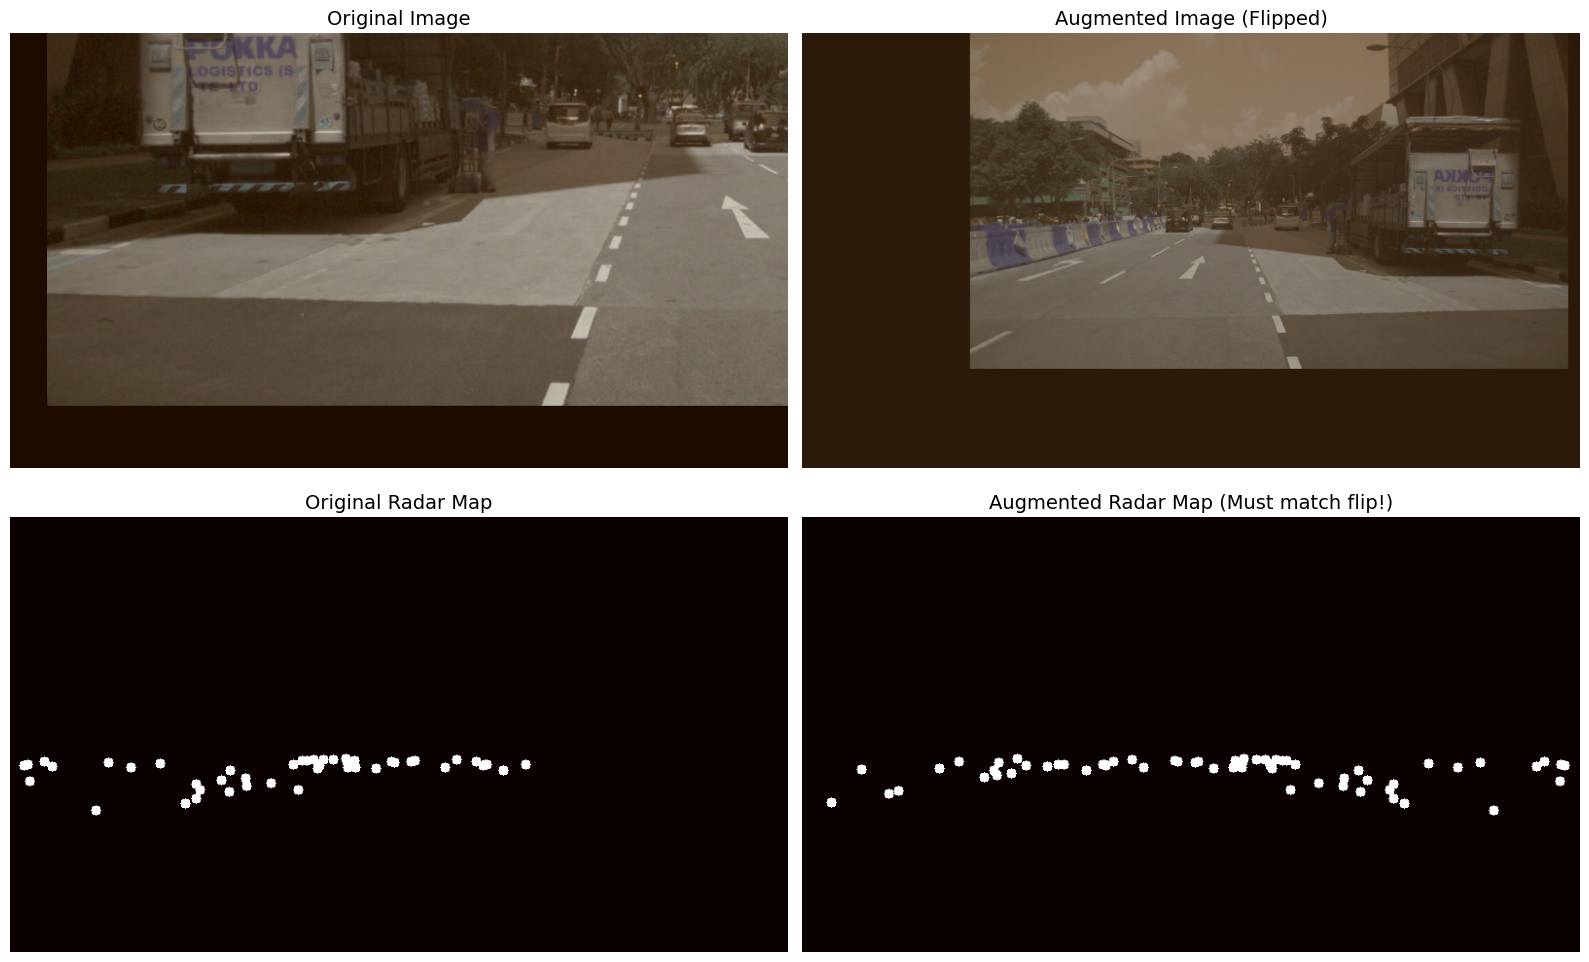

In [8]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# 1. Add the internal library paths
sys.path.append('/kaggle/working/CenterFusion/src/lib')
from opts import opts
from dataset.dataset_factory import dataset_factory

def create_dataset(flip_probability):
    """Helper function to initialize the dataset with specific flip settings"""
    
    # THE FIX: We added '--pointcloud' and '--radar_sweeps', '6' to wake up the radar loader!
    opt = opts().parse([
        'ddd', 
        '--dataset', 'nuscenes', 
        '--pointcloud', 
        '--radar_sweeps', '6'
    ])
    
    # Inject the required variables
    opt.data_dir = '/kaggle/working/CenterFusion/data'
    opt.dataset_version = 'v1.0-mini'
    opt.heads = {'hm': 10, 'reg': 2, 'wh': 2, 'dep': 1, 'rot': 8, 'dim': 3, 'velocity': 3}
    opt.num_classes = 10 
    opt.input_w = 800
    opt.input_h = 448
    opt.down_ratio = 4
    opt.output_w = opt.input_w // opt.down_ratio
    opt.output_h = opt.input_h // opt.down_ratio
    
    # Force augmentation settings
    opt.flip = flip_probability
    opt.scale = 0.0  # Kept at 0 so we can compare the exact pixel mirroring
    opt.shift = 0.0
    
    Dataset = dataset_factory[opt.dataset]
    return Dataset(opt, 'mini_train')

# 2. Initialize two versions of the dataset
print("Loading Original Dataset...")
dataset_original = create_dataset(flip_probability=0.0)

print("Loading Augmented Dataset...")
dataset_augmented = create_dataset(flip_probability=1.0)

# 3. Pull the exact same sample from both
sample_idx = 0
batch_orig = dataset_original[sample_idx]
batch_aug = dataset_augmented[sample_idx]

import cv2

# 4. Helper function to extract, denormalize, and ENHANCE images
def extract_visuals(batch):
    img_tensor = batch['image']
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)
    
    if hasattr(img_tensor, 'cpu'):
        img_tensor = img_tensor.cpu().numpy()
        
    rgb = ((img_tensor[:3, :, :] * std + mean).transpose(1, 2, 0) * 255).clip(0, 255).astype(np.uint8)
    
    # Blank canvas
    radar_visible = np.zeros((img_tensor.shape[1], img_tensor.shape[2]), dtype=np.uint8)
    
    if 'pc_2d' in batch:
        pc_2d = batch['pc_2d']
        if hasattr(pc_2d, 'cpu'): pc_2d = pc_2d.cpu().numpy()
            
        pc_N_raw = batch.get('pc_N', pc_2d.shape[1] if len(pc_2d.shape) > 1 else 0)
        try:
            pc_N = int(np.squeeze(pc_N_raw))
        except Exception:
            pc_N = int(pc_N_raw[0]) 
            
        # THE FIX: pc_2d is in 1600x900. We must scale it to the 800x448 tensor size!
        orig_w, orig_h = 1600.0, 900.0
        target_h, target_w = radar_visible.shape
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h
        
        # CenterFusion's typical shape for pc_2d is [3, N] -> [x, y, depth]
        if pc_2d.shape[0] in [2, 3]:
            xs = pc_2d[0, :pc_N]
            ys = pc_2d[1, :pc_N]
        else:
            xs = pc_2d[:pc_N, 0]
            ys = pc_2d[:pc_N, 1]
            
        import cv2
        points_plotted = 0
        
        # Plot points using the correct downscaling
        for x, y in zip(xs, ys):
            ix, iy = int(x * scale_x), int(y * scale_y)
            if 0 <= ix < target_w and 0 <= iy < target_h:
                # Draw a bright white, visible circle
                cv2.circle(radar_visible, (ix, iy), radius=5, color=(255,), thickness=-1)
                points_plotted += 1
                
        if points_plotted == 0:
            print(f"NOTE: 0 radar points mapped on screen. (pc_N was {pc_N}).")
    else:
        print(f"Warning: No radar keys ('pc_2d') found! Available keys: {list(batch.keys())}")
        
    return rgb, radar_visible

# Re-run your extraction
rgb_orig, radar_orig = extract_visuals(batch_orig)
rgb_aug, radar_aug = extract_visuals(batch_aug)

# 5. Plot the Ultimate Verification Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top Left: Original RGB
axes[0, 0].imshow(rgb_orig)
axes[0, 0].set_title("Original Image", fontsize=14)
axes[0, 0].axis('off')

# Top Right: Flipped RGB
axes[0, 1].imshow(rgb_aug)
axes[0, 1].set_title("Augmented Image (Flipped)", fontsize=14)
axes[0, 1].axis('off')

# Bottom Left: Original Radar
axes[1, 0].imshow(radar_orig, cmap='hot')
axes[1, 0].set_title("Original Radar Map", fontsize=14)
axes[1, 0].axis('off')

# Bottom Right: Flipped Radar
axes[1, 1].imshow(radar_aug, cmap='hot')
axes[1, 1].set_title("Augmented Radar Map (Must match flip!)", fontsize=14)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

---
## 1. Paths & sys.path setup

In [9]:
import sys, os

REPO = '/kaggle/working/CenterFusion'
sys.path.insert(0, os.path.join(REPO, 'src', 'lib'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
print(f'Device: {DEVICE}')

Device: cuda


---
## 2. Paste model definitions from walkthrough notebook

Copy every class definition from `centerfusion_walkthrough.ipynb` cells 3–9 here.
They are reproduced below with **one critical fix already applied**: the `SimpleDecoder`
no longer upsamples back to full resolution — it stays at `H/R × W/R` to match
the radar feature maps (this was the `RuntimeError: Sizes must match` bug).

In [10]:
# ── paste from centerfusion_walkthrough.ipynb ──────────────────────────────
# RadarPoint, DetectedObject dataclasses
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

@dataclass
class RadarPoint:
    x: float; y: float; z: float; vx: float; vy: float
    def to_tensor(self): return torch.tensor([self.x,self.y,self.z,self.vx,self.vy])

@dataclass
class DetectedObject:
    cx: float; cy: float; w: float; h: float
    depth: float; dim: Tuple; score: float = 1.0

# ── Backbone ──────────────────────────────────────────────────────────────
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)

class SimpleEncoder(nn.Module):
    def __init__(self, in_channels=3, base_channels=64):
        super().__init__()
        c = base_channels
        self.stage1 = nn.Sequential(ConvBNReLU(in_channels,c), ConvBNReLU(c,c))
        self.down1  = nn.MaxPool2d(2,2)
        self.stage2 = nn.Sequential(ConvBNReLU(c,c*2), ConvBNReLU(c*2,c*2))
        self.down2  = nn.MaxPool2d(2,2)
        self.stage3 = nn.Sequential(ConvBNReLU(c*2,c*4), ConvBNReLU(c*4,c*4))
        self.out_channels = c*4
    def forward(self, x):
        x = self.down1(self.stage1(x))
        x = self.down2(self.stage2(x))
        return self.stage3(x)  # (B, C*4, H/4, W/4)

class SimpleDecoder(nn.Module):
    """
    FIX vs walkthrough: we do NOT upsample back to full resolution.
    The paper keeps all feature maps at stride R=4 (H/4 x W/4).
    Upsampling here caused the H=224 vs H=56 mismatch in torch.cat.
    """
    def __init__(self, in_channels, out_channels=64):
        super().__init__()
        self.refine = nn.Sequential(
            ConvBNReLU(in_channels, in_channels//2),
            ConvBNReLU(in_channels//2, out_channels),
        )
        self.out_channels = out_channels
    def forward(self, x): return self.refine(x)  # stays at H/4 x W/4

class CenterNetBackbone(nn.Module):
    def __init__(self, img_channels=3, feature_channels=64):
        super().__init__()
        self.encoder = SimpleEncoder(img_channels)
        self.decoder = SimpleDecoder(self.encoder.out_channels, feature_channels)
        self.out_channels = feature_channels
    def forward(self, img):
        return self.decoder(self.encoder(img))  # (B, feature_channels, H/4, W/4)

# ── Primary heads ──────────────────────────────────────────────────────────
class RegressionHead(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=256):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, 1, bias=True))
    def forward(self, x): return self.head(x)

class PrimaryHeads(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super().__init__()
        self.heatmap = RegressionHead(in_channels, num_classes)
        self.wh      = RegressionHead(in_channels, 2)
        self.offset  = RegressionHead(in_channels, 2)
        self.depth   = RegressionHead(in_channels, 1)
        self.dim     = RegressionHead(in_channels, 3)
        self.rot     = RegressionHead(in_channels, 8)
    def forward(self, features):
        hm  = torch.sigmoid(self.heatmap(features))
        dep = 1.0 / (torch.sigmoid(self.depth(features)) + 1e-6) - 1.0
        return dict(hm=hm, wh=self.wh(features), off=self.offset(features),
                    dep=dep, dim=self.dim(features), rot=self.rot(features))

# ── Frustum association ────────────────────────────────────────────────────
def build_roi_frustum(obj, K, delta=0.2):
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    d = obj.depth
    x_left  = (obj.cx - obj.w/2 - cx)*d/fx
    x_right = (obj.cx + obj.w/2 - cx)*d/fx
    l, w, h = obj.dim
    return dict(x_min=x_left  - delta*abs(x_right-x_left),
                x_max=x_right + delta*abs(x_right-x_left),
                depth_min=d-(1+delta)*l/2, depth_max=d+(1+delta)*l/2,
                z_min=-h, z_max=h)

def is_point_in_frustum(pt, f, pillar_half=0.75):
    return (f['depth_min']<=pt.x<=f['depth_max'] and
            f['x_min']<=pt.y<=f['x_max'] and
            (pt.z-pillar_half)<=f['z_max'] and (pt.z+pillar_half)>=f['z_min'])

def frustum_associate(obj, radar_points, K, delta=0.2):
    frustum = build_roi_frustum(obj, K, delta)
    cands = [p for p in radar_points if is_point_in_frustum(p, frustum)]
    return min(cands, key=lambda p: np.sqrt(p.x**2+p.y**2)) if cands else None

# ── Radar feature maps ────────────────────────────────────────────────────
def generate_radar_feature_maps(detections, radar_associations, feat_h, feat_w,
                                 R=4, alpha=0.5, M_d=100.0, M_v=20.0):
    radar_maps = torch.zeros(3, feat_h, feat_w)
    depth_map  = torch.full((feat_h, feat_w), float('inf'))
    for obj, rp in zip(detections, radar_associations):
        if rp is None: continue
        cx_f = int(obj.cx/R); cy_f = int(obj.cy/R)
        hw = int(alpha*obj.w/R); hh = int(alpha*obj.h/R)
        x0,x1 = max(0,cx_f-hw), min(feat_w,cx_f+hw+1)
        y0,y1 = max(0,cy_f-hh), min(feat_h,cy_f+hh+1)
        if x0>=x1 or y0>=y1: continue
        mask = rp.x < depth_map[y0:y1,x0:x1]
        radar_maps[0,y0:y1,x0:x1][mask] = rp.x/M_d
        radar_maps[1,y0:y1,x0:x1][mask] = rp.vx/M_v
        radar_maps[2,y0:y1,x0:x1][mask] = rp.vy/M_v
        depth_map[y0:y1,x0:x1][mask]    = rp.x
    return radar_maps

# ── Secondary heads ────────────────────────────────────────────────────────
class SecondaryRegressionHead(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=256):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_channels,  mid_channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, 1))
    def forward(self, x): return self.head(x)

class SecondaryHeads(nn.Module):
    def __init__(self, img_channels, radar_channels=3, num_attrs=8):
        super().__init__()
        fused = img_channels + radar_channels
        self.depth = SecondaryRegressionHead(fused, 1)
        self.rot   = SecondaryRegressionHead(fused, 8)
        self.vel   = SecondaryRegressionHead(fused, 2)
        self.attr  = SecondaryRegressionHead(fused, num_attrs)
    def forward(self, img_features, radar_maps):
        fused = torch.cat([img_features, radar_maps], dim=1)
        return dict(dep=1.0/(torch.sigmoid(self.depth(fused))+1e-6)-1.0,
                    rot=self.rot(fused), vel=self.vel(fused), attr=self.attr(fused))

# ── Full model ─────────────────────────────────────────────────────────────
class CenterFusion(nn.Module):
    def __init__(self, num_classes=10, img_channels=3, feature_channels=64,
                 camera_K=None, R=4, delta=0.2, alpha=0.5, hm_thresh=0.3):
        super().__init__()
        self.R=R; self.delta=delta; self.alpha=alpha; self.hm_thresh=hm_thresh
        self.K = camera_K if camera_K is not None else np.eye(3)
        self.backbone        = CenterNetBackbone(img_channels, feature_channels)
        self.primary_heads   = PrimaryHeads(feature_channels, num_classes)
        self.secondary_heads = SecondaryHeads(feature_channels, radar_channels=3)

    def forward(self, images, radar_points):
        B, _, H, W = images.shape
        feat_h, feat_w = H//self.R, W//self.R
        img_features = self.backbone(images)
        primary_out  = self.primary_heads(img_features)

        radar_feat_batch = torch.zeros(B, 3, feat_h, feat_w, device=images.device)
        for b in range(B):
            dets = self._decode_preliminary(primary_out, b)
            assoc = [frustum_associate(d, radar_points[b], self.K, self.delta) for d in dets]
            radar_feat_batch[b] = generate_radar_feature_maps(
                dets, assoc, feat_h, feat_w, self.R, self.alpha)

        secondary_out = self.secondary_heads(img_features, radar_feat_batch)
        return dict(primary=primary_out, secondary=secondary_out,
                    radar_maps=radar_feat_batch)

    def _decode_preliminary(self, primary_out, batch_idx):
        hm  = primary_out['hm'][batch_idx]
        dep = primary_out['dep'][batch_idx]
        wh  = primary_out['wh'][batch_idx]
        dim = primary_out['dim'][batch_idx]
        peak = hm.max(0).values
        ys, xs = (peak > self.hm_thresh).nonzero(as_tuple=True)
        objs = []
        for y, x in zip(ys.tolist(), xs.tolist()):
            objs.append(DetectedObject(
                cx=x*self.R, cy=y*self.R,
                w=max(float(wh[0,y,x]),1), h=max(float(wh[1,y,x]),1),
                depth=max(float(dep[0,y,x]),0.1),
                dim=tuple(float(dim[i,y,x]) for i in range(3))))
        return objs

print('All model classes defined.')

All model classes defined.


---
## 3. Loss functions

Paste from `centerfusion_walkthrough.ipynb` Cell 10 (CenterFusionLoss).

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Focal Loss
def focal_loss(pred, target, alpha=2.0, beta=4.0):
    eps  = 1e-6
    pred = pred.clamp(eps, 1-eps)
    pos  = (target==1).float()
    neg  = (target<1).float()
    N    = pos.sum().clamp(min=1)
    return ((-pos*(1-pred).pow(alpha)*torch.log(pred))
            +(-neg*(1-target).pow(beta)*pred.pow(alpha)*torch.log(1-pred))).sum()/N

# 2. Gathering & Masking Helpers
def transpose_and_gather_feat(feat, ind):
    feat = feat.permute(0, 2, 3, 1).contiguous()
    feat = feat.view(feat.size(0), -1, feat.size(3))
    ind = ind.unsqueeze(2).expand(ind.size(0), ind.size(1), feat.size(2))
    feat = feat.gather(1, ind)
    return feat

def masked_l1_loss(pred, target, mask):
    mask = mask.unsqueeze(2).expand_as(pred).float()
    loss = F.l1_loss(pred * mask, target * mask, reduction='sum')
    return loss / (mask.sum() + 1e-4)

# 3. UPDATED CenterFusionLoss
class CenterFusionLoss(nn.Module):
    def __init__(self, weights=None):
        super().__init__()
        self.w = weights or dict(hm=1.0, wh=0.1, off=1.0,
                                  dep=1.0, dim=1.0, rot=1.0,
                                  vel=1.0, attr=1.0)
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, pred, target):
        p, s = pred['primary'], pred['secondary']
        
        ind  = target['ind']
        mask = target['mask']

        # --- THE FIX ---
        # If the dataloader provides reg_mask as [B, 128, 2], squash it to [B, 128]
        if mask.dim() > 2:
            mask = mask[:, :, 0]
        # ---------------

        # Gather primary features
        pred_wh  = transpose_and_gather_feat(p['wh'], ind)
        pred_off = transpose_and_gather_feat(p['off'], ind)
        pred_dep = transpose_and_gather_feat(p['dep'], ind)
        pred_dim = transpose_and_gather_feat(p['dim'], ind)
        pred_rot = transpose_and_gather_feat(p['rot'], ind)
        
        # Gather secondary features
        pred_vel  = transpose_and_gather_feat(s['vel'], ind)
        pred_attr = transpose_and_gather_feat(s['attr'], ind)

        # Masked BCE for attributes
        attr_mask = mask.unsqueeze(2).expand_as(pred_attr).float()
        attr_loss = (self.bce(pred_attr, target['attr']) * attr_mask).sum() / (attr_mask.sum() + 1e-4)

        # Calculate final masked losses
        losses = {
            'hm':  focal_loss(p['hm'], target['hm']) * self.w['hm'],
            'wh':  masked_l1_loss(pred_wh,  target['wh'],  mask) * self.w['wh'],
            'off': masked_l1_loss(pred_off, target['off'], mask) * self.w['off'],
            'dep': masked_l1_loss(pred_dep, target['dep'], mask) * self.w['dep'],
            'dim': masked_l1_loss(pred_dim, target['dim'], mask) * self.w['dim'],
            'rot': masked_l1_loss(pred_rot, target['rot'], mask) * self.w['rot'],
            'vel': masked_l1_loss(pred_vel, target['vel'], mask) * self.w['vel'],
            'attr': attr_loss * self.w['attr'],
        }
        
        losses['total'] = sum(losses.values())
        return losses

criterion = CenterFusionLoss()
print('CenterFusionLoss defined (with dynamic mask squashing).')

CenterFusionLoss defined (with dynamic mask squashing).


---
## 4. Load nuScenes dataset

Reusing the exact `create_dataset` setup from `nuscenes_dataset_headache.ipynb` Cell 8.

In [12]:
from opts import opts
from dataset.dataset_factory import dataset_factory

def make_opt(split):
    opt = opts().parse([
        'ddd',
        '--dataset',      'nuscenes',
        '--pointcloud',
        '--radar_sweeps', '6'
    ])
    opt.data_dir        = os.path.join(REPO, 'data')
    opt.dataset_version = 'v1.0-mini'
    opt.heads           = {'hm': 10, 'reg': 2, 'wh': 2,
                           'dep': 1, 'rot': 8, 'dim': 3, 'velocity': 3}
    opt.num_classes  = 10
    opt.input_w      = 800
    opt.input_h      = 448
    opt.down_ratio   = 4
    opt.output_w     = opt.input_w  // opt.down_ratio  # 200
    opt.output_h     = opt.input_h  // opt.down_ratio  # 112
    opt.flip         = 0.5 if split == 'mini_train' else 0.0
    opt.scale        = 0.0
    opt.shift        = 0.0
    return opt

Dataset = dataset_factory['nuscenes']
train_dataset = Dataset(make_opt('mini_train'), 'mini_train')
val_dataset   = Dataset(make_opt('mini_val'),   'mini_val')

print(f'Train samples: {len(train_dataset)}')
print(f'Val   samples: {len(val_dataset)}')

Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_train data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_train.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=4.11s)
creating index...
index created!
Loaded mini_train 1938 samples
Fix size testing.
training chunk_sizes: [32]
Dataset version v1.0-mini
==> initializing mini_val data from /kaggle/working/CenterFusion/data/nuscenes/annotations_6sweeps/mini_val.json, 
 images from /kaggle/working/CenterFusion/data/nuscenes ...
loading annotations into memory...
Done (t=1.10s)
creating index...
index created!
Loaded mini_val 486 samples
Train samples: 1938
Val   samples: 486


---
## 5. Collate function

The nuScenes dataset returns dicts with mixed types (tensors, lists, numpy arrays).
This collate function handles all of them so DataLoader works correctly.

In [14]:
def centerfusion_collate(batch):
    """
    batch: list of dicts from the nuScenes Dataset.__getitem__.

    Returns a single dict where:
    - tensors are stacked along dim 0
    - radar_points is a list-of-lists (one list of RadarPoint per sample)
    - everything else falls through as a list
    """
    out = {}
    keys = batch[0].keys()
    for k in keys:
        vals = [b[k] for b in batch]
        if isinstance(vals[0], torch.Tensor):
            out[k] = torch.stack(vals, dim=0)
        elif isinstance(vals[0], np.ndarray):
            out[k] = torch.from_numpy(np.stack(vals, axis=0))
        else:
            out[k] = vals  # keep as list (e.g. radar_points, meta)
    return out


def batch_to_radar_points(batch):
    """
    Convert the raw pc_2d / pc_3d tensors from the nuScenes loader
    into the List[List[RadarPoint]] format expected by CenterFusion.forward.

    nuScenes loader stores radar as:
        pc_2d  : (B, 3, N_max)  — [u, v, depth] in image pixels
        pc_3d  : (B, 5, N_max)  — [x, y, z, vx, vy] in ego metres
        pc_N   : (B,)           — number of valid points per sample
    """
    B = batch['image'].shape[0]
    radar_batch = []

    pc3d = batch.get('pc_3d')   # (B, channels, N) or None
    pc_N = batch.get('pc_N')    # (B,) or None

    for b in range(B):
        pts = []
        if pc3d is not None and pc_N is not None:
            n = int(pc_N[b]) if not isinstance(pc_N[b], int) else pc_N[b]
            for i in range(n):
                # FIX: Slice only the first 5 channels to prevent unpacking errors
                # if the dataloader outputs more features (like rcs or raw 18 dims)
                x, y, z, vx, vy = pc3d[b, :5, i].tolist()
                
                pts.append(RadarPoint(x=x, y=y, z=z, vx=vx, vy=vy))
        radar_batch.append(pts)

    return radar_batch


def build_targets(batch, feat_h, feat_w, num_classes, device):
    """
    Build the ground-truth tensors that CenterFusionLoss expects.
    We grab the sparse object lists (max 128 objects) along with their indices and masks.
    """
    def _get(key, fallback_shape):
        v = batch.get(key)
        if v is None:
            return torch.zeros(fallback_shape, device=device)
        if isinstance(v, np.ndarray):
            v = torch.from_numpy(v)
        return v.to(device).float()

    B = batch['image'].shape[0]
    
    # Notice the fallback shapes are now mostly [B, 128, C] for the regression heads
    return {
        'hm':   _get('hm',       (B, num_classes, feat_h, feat_w)),
        'wh':   _get('wh',       (B, 128, 2)),
        'off':  _get('reg',      (B, 128, 2)),   # 'reg' → 'off'
        'dep':  _get('dep',      (B, 128, 1)),
        'dim':  _get('dim',      (B, 128, 3)),
        'rot':  _get('rot',      (B, 128, 8)),
        'vel':  _get('velocity', (B, 128, 3))[:, :, :2], 
        
        # --- THESE ARE CRITICAL FOR LOSS MASKING ---
        'ind':  _get('ind',      (B, 128)).to(torch.int64), # Valid object locations
        'mask': _get('reg_mask', (B, 128)),                 # 1 for valid, 0 for empty padding
        'attr': torch.zeros(B, 128, 8, device=device),
    }

---
## 6. DataLoaders

In [15]:
BATCH_SIZE  = 4   # reduce to 2 if you hit OOM on a 16 GB GPU
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=centerfusion_collate,
    pin_memory=(DEVICE=='cuda'),
    drop_last=True,    # keeps batch size fixed; avoids BN issues on last tiny batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=centerfusion_collate,
    pin_memory=(DEVICE=='cuda'),
)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')

# Inspect one batch to confirm shapes
sample_batch = next(iter(train_loader))
print('\nBatch keys:', list(sample_batch.keys()))
print('image  shape:', sample_batch['image'].shape)    # (B, 3, 448, 800)
if 'hm' in sample_batch:
    print('hm     shape:', sample_batch['hm'].shape)   # (B, 10, 112, 200)
if 'pc_3d' in sample_batch:
    print('pc_3d  shape:', sample_batch['pc_3d'].shape)

Train batches: 484
Val   batches: 122

Batch keys: ['image', 'pc_2d', 'pc_3d', 'pc_N', 'pc_dep', 'hm', 'ind', 'cat', 'mask', 'pc_hm', 'reg', 'reg_mask', 'wh', 'wh_mask', 'velocity', 'velocity_mask', 'dep', 'dep_mask', 'dim', 'dim_mask', 'rotbin', 'rotres', 'rot_mask', 'calib']
image  shape: torch.Size([4, 3, 448, 800])
hm     shape: torch.Size([4, 10, 112, 200])
pc_3d  shape: torch.Size([4, 18, 1000])


---
## 7. Model, optimiser, scheduler

Camera intrinsics below are nuScenes CAM_FRONT defaults (800×448 crop).

In [16]:
# nuScenes CAM_FRONT intrinsics (approximate, resized to 800x448)
K = np.array([[800.0,   0.0, 400.0],
              [  0.0, 800.0, 224.0],
              [  0.0,   0.0,   1.0]], dtype=np.float64)

model = CenterFusion(
    num_classes=10,
    feature_channels=64,
    camera_K=K,
    R=4,
    delta=0.2,
    alpha=0.5,
    hm_thresh=0.3,
).to(DEVICE)

criterion = CenterFusionLoss()

# Paper uses Adam, lr=1.25e-4, halved at epochs 90 and 120 (full dataset)
# On mini we train for far fewer epochs, so we start a bit higher and
# step at epoch 20 and 30.
LR      = 1.25e-4
EPOCHS  = 40

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[20, 30], gamma=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(f'LR={LR}  Epochs={EPOCHS}  BatchSize={BATCH_SIZE}')

Model parameters: 7,752,301
LR=0.000125  Epochs=40  BatchSize=4


---
## 8. Training loop

In [ ]:
import time

FEAT_H = 448 // 4   # 112
FEAT_W = 800 // 4   # 200
NUM_CLASSES = 10

history = {'train_loss': [], 'val_loss': []}


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    n_batches   = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            images = batch['image'].to(DEVICE).float()
            radar  = batch_to_radar_points(batch)
            target = build_targets(batch, FEAT_H, FEAT_W, NUM_CLASSES, DEVICE)

            outputs = model(images, radar)
            losses  = criterion(outputs, target)
            loss    = losses['total']

            if training:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping — helpful for the early unstable epochs
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=35)
                optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

    return total_loss / max(n_batches, 1)


best_val = float('inf')
CKPT_PATH = os.path.join(REPO, 'centerfusion_best.pth')

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    train_loss = run_epoch(train_loader, training=True)
    val_loss   = run_epoch(val_loader,   training=False)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'train={train_loss:.4f}  val={val_loss:.4f} | '
          f'lr={lr_now:.2e} | {elapsed:.1f}s')

    # Save best checkpoint
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            'epoch':      epoch,
            'model':      model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'val_loss':   val_loss,
        }, CKPT_PATH)
        print(f'  ✓ checkpoint saved (val={val_loss:.4f})')

print(f'\nDone. Best val loss: {best_val:.4f}  →  {CKPT_PATH}')

---
## 9. Loss curve

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss'])+1)
plt.figure(figsize=(9,4))
plt.plot(epochs, history['train_loss'], label='train')
plt.plot(epochs, history['val_loss'],   label='val')
plt.xlabel('Epoch'); plt.ylabel('Total loss')
plt.title('CenterFusion training on nuScenes-mini')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

---
## 10. Load best checkpoint and quick inference smoke-test

In [24]:
FEAT_H = 448 // 4   # 112
FEAT_W = 800 // 4   # 200
NUM_CLASSES = 10

history = {'train_loss': [], 'val_loss': []}

CKPT_PATH = os.path.join(REPO, 'centerfusion_best.pth')
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (val_loss={ckpt["val_loss"]:.4f})')

# Run one validation batch and print per-head losses
sample = next(iter(val_loader))
images  = sample['image'].to(DEVICE).float()
radar   = batch_to_radar_points(sample)
target  = build_targets(sample, FEAT_H, FEAT_W, NUM_CLASSES, DEVICE)

with torch.no_grad():
    out    = model(images, radar)
    losses = criterion(out, target)

print('\nPer-head losses on one val batch:')
for k, v in losses.items():
    print(f'  {k:6s}: {v.item():.4f}')

print('\nPrimary output shapes:')
for k, v in out['primary'].items():
    print(f'  {k}: {tuple(v.shape)}')

print('\nSecondary output shapes:')
for k, v in out['secondary'].items():
    print(f'  {k}: {tuple(v.shape)}')

# Model accuracy
total_hits = 0
total_predictions = 0

print("Calculating Detection Accuracy (Hit Rate)...")

with torch.no_grad():
    for batch in val_loader:
        # Extract inputs
        images = batch['image'].to(DEVICE).float()
        radar  = batch_to_radar_points(batch)
        
        # Forward pass
        outputs = model(images, radar)
        primary_out = outputs['primary']
        
        B = images.size(0)
        
        for b in range(B):
            # 1. Get model predictions (bounding boxes/centers) for this image
            pred_objs = model._decode_preliminary(primary_out, b)
            
            # 2. Get the ground truth heatmap for this image
            # Shape: [num_classes, H, W]
            gt_hm = batch['hm'][b].to(DEVICE) 
            
            for obj in pred_objs:
                total_predictions += 1
                
                # Convert the object's center back to feature map coordinates
                feat_x = int(obj.cx / model.R)
                feat_y = int(obj.cy / model.R)
                
                # Bound check
                feat_x = max(0, min(feat_x, FEAT_W - 1))
                feat_y = max(0, min(feat_y, FEAT_H - 1))
                
                # If the ground truth heatmap has a high confidence (> 0.3) at this location
                # it means there is actually an object there (a "hit")
                if gt_hm[:, feat_y, feat_x].max() > 0.3:
                    total_hits += 1

# Calculate final accuracy percentage
if total_predictions > 0:
    accuracy = (total_hits / total_predictions) * 100
else:
    accuracy = 0.0

print(f'Total Predictions made: {total_predictions}')
print(f'Correct Predictions (Hits): {total_hits}')
print(f'Detection Accuracy: {accuracy:.2f}%')

Loaded checkpoint from epoch 35 (val_loss=11.5990)

Per-head losses on one val batch:
  hm    : 2.2089
  wh    : 0.2826
  off   : 0.2500
  dep   : 8.2419
  dim   : 0.2533
  rot   : 0.0003
  vel   : 0.2834
  attr  : 0.0000
  total : 11.5204

Primary output shapes:
  hm: (4, 10, 112, 200)
  wh: (4, 2, 112, 200)
  off: (4, 2, 112, 200)
  dep: (4, 1, 112, 200)
  dim: (4, 3, 112, 200)
  rot: (4, 8, 112, 200)

Secondary output shapes:
  dep: (4, 1, 112, 200)
  rot: (4, 8, 112, 200)
  vel: (4, 2, 112, 200)
  attr: (4, 8, 112, 200)
Calculating Detection Accuracy (Hit Rate)...
Total Predictions made: 1890
Correct Predictions (Hits): 365
Detection Accuracy: 19.31%


In [ ]:
# !git init
# !git remote add origin https://github.com/Sir2m/CenterFusion.git
# !git branch -m main

!git push origin main